In [28]:
# %pip install openpyxl

In [29]:
import pandas as pd
import numpy as np

# viz...
import seaborn as sns
import matplotlib.pyplot as plt

# my own custom lib
import vizion as vz

In [30]:
df = pd.read_excel("Online_Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [48]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406784 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406784 non-null  object        
 1   StockCode    406784 non-null  object        
 2   Description  406784 non-null  object        
 3   Quantity     406784 non-null  int64         
 4   InvoiceDate  406784 non-null  datetime64[ns]
 5   UnitPrice    406784 non-null  float64       
 6   CustomerID   406784 non-null  float64       
 7   Country      406784 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


In [32]:
vz.help_steps()

=== VIZION CLASS STEP-BY-STEP GUIDE ===
STEP 1: Load your dataset into a pandas DataFrame (df).
STEP 2: Quick overview of data:
        Vizion.quick_summary(df)  # basic stats and missing info
STEP 3: Check missing values in detail:
        Vizion.missing_value_summary(df)
STEP 4: Set global column types (numeric, categorical, missing):
        Vizion.get_column_types(df)
STEP 5: Handle missing values:
        df_clean, report = Vizion.handle_missing(df)  # drops/fills missing
STEP 6: Explore numeric columns with visual EDA:
        Vizion.plot_numeric_eda(df_clean)  # hist, box, kde, scatter
STEP 7: Explore categorical columns with visual EDA:
        Vizion.plot_categorical_eda(df_clean)  # count, bar, box, pie
STEP 8: Detect and handle outliers:
        df_clean = Vizion.handle_outliers(df_clean)  # cap/remove outliers
STEP 9: After EDA, you can perform feature engineering, encoding, scaling etc.
STEP 10: Build models (optional guidance):
        Use 'next_steps(df_clean, target="yo

In [33]:
vz.quick_summary(df)

===== SIMPLE DATA SUMMARY =====
Rows       : 541909
Columns    : 8
Numeric    : 3
Categorical: 4
Datetime   : 1
Missing columns: 2
Duplicated rows: 5268

Top Missing Columns (%):
  - CustomerID: 24.93%
  - Description: 0.27%

Top Missing Categorical Columns (%):
  - Description: 0.27%


In [34]:
num_col = df.select_dtypes(include=[np.number]).columns.tolist()
cat_col = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
mis_col = df.columns[df.isnull().sum() > 0].tolist()

In [35]:
df['CustomerID'].value_counts()
df['CustomerID'].nunique()

4372

In [36]:
df[mis_col].value_counts()

Description                       CustomerID
CARRIAGE                          14911.0       85
CHILLI LIGHTS                     17841.0       65
REGENCY CAKESTAND 3 TIER          14911.0       56
PACK OF 60 DINOSAUR CAKE CASES    17841.0       54
BLUE/CREAM STRIPE CUSHION COVER   17841.0       54
                                                ..
ZINC WIRE SWEETHEART LETTER TRAY  17530.0        1
CHILDS GARDEN TROWEL PINK         17611.0        1
ZINC WIRE SWEETHEART LETTER TRAY  17812.0        1
                                  17835.0        1
                                  13405.0        1
Name: count, Length: 269157, dtype: int64

In [37]:
df= df.dropna(subset=["CustomerID"])

#### Justification : Dropping rows with missing CustomerID for RFM/customer analysis

In [38]:
vz.quick_summary(df)

===== SIMPLE DATA SUMMARY =====
Rows       : 406829
Columns    : 8
Numeric    : 3
Categorical: 4
Datetime   : 1
Missing columns: 0
Duplicated rows: 5225

Top Missing Columns (%):

Top Missing Categorical Columns (%):
  No missing categorical columns


In [52]:
for i in df.columns.to_list():
    print(i," : ",df[i].unique())
    print('----------------------------------------')

InvoiceNo  :  [536365 536366 536367 ... 581585 581586 581587]
----------------------------------------
StockCode  :  ['85123A' 71053 '84406B' ... '90214W' '90214Z' 90089]
----------------------------------------
Description  :  ['WHITE HANGING HEART T-LIGHT HOLDER' 'WHITE METAL LANTERN'
 'CREAM CUPID HEARTS COAT HANGER' ... 'LETTER "Z" BLING KEY RING'
 'PINK CRYSTAL SKULL PHONE CHARM' 'CREAM HANGING HEART T-LIGHT HOLDER']
----------------------------------------
Quantity  :  [    6     8     2    32     3     4    24    12    48    18    20    36
    80    64    10   120    96    23     5     1    -1    50    40   100
   192   432   144   288   -12   -24    16     9   128    25    30    28
     7    72   200   600   480    -6    14    -2    -4    -5    -7    -3
    11    70   252    60   216   384    27   108    52    75   270    42
   240    90   320    17  1824   204    69   -36  -192  -144   160  2880
  1400    19    39   -48   -50    56    13  1440    -8    15   720   -20
   156   

In [39]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [40]:
df[df.duplicated()].head(3)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom


## Same User Will Do Multiple Transactions

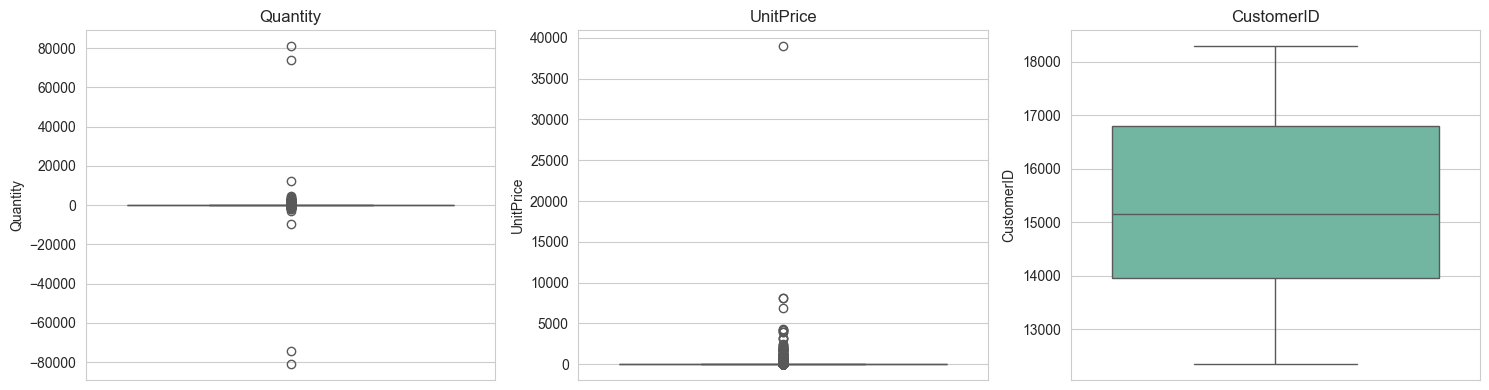

In [41]:
vz.plot_columns(df,df.select_dtypes(include=['int64','float64']).columns.to_list(),plot_type='box')

## Removing Unrealistic Extreme Values

<Axes: ylabel='Quantity'>

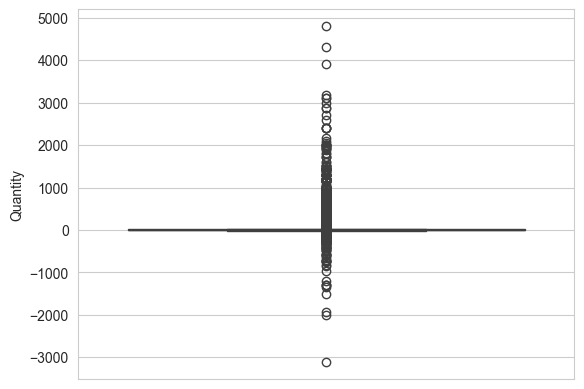

In [46]:
df = df[(df['Quantity'] > -10000) & (df['Quantity'] < 10000)]
sns.boxplot(data=df,y='Quantity')

In [45]:
df = df[(df['Quantity'] > -8000) & (df['Quantity'] < 10000)]


## About UnitPrice - some prices = 0 or negative, which is invalid.

In [47]:
df = df[df['UnitPrice'] > 0]

## CustomerID is not numerical feature it is categorical mean should be unique for each
### skipping CustomerID as Outliers / Missing

In [54]:
# converting string into datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Data Is ready For Visualization

In [49]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

# Q1 - Which Product And Customer Groups generate the highest revenue 

In [53]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

### Revenue By Month 

<Axes: xlabel='month'>

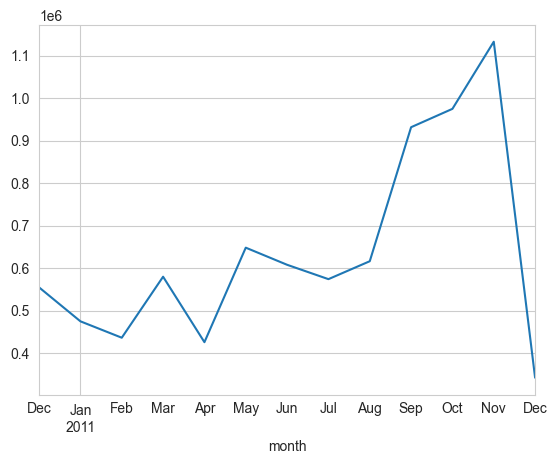

In [66]:
df["month"] = df["InvoiceDate"].dt.to_period("M")

monthly = df.groupby("month")["Revenue"].sum()
monthly.plot(kind="line")

## Top 10 product by revenue

<Axes: ylabel='Description'>

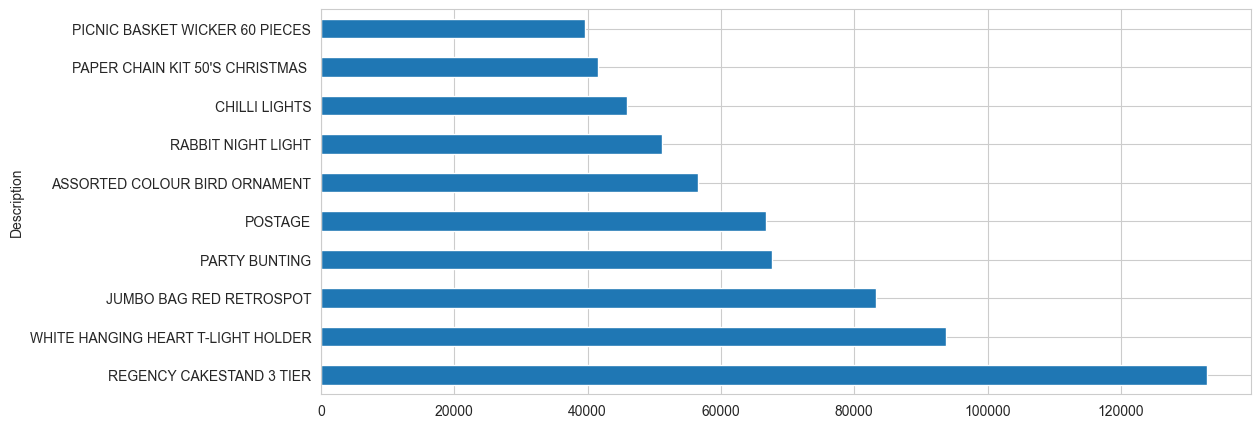

In [67]:
product_rev = df.groupby("Description")["Revenue"].sum().nlargest(10)
product_rev.plot.barh(figsize=(12,5))

## Top Customers Revenue

<Axes: ylabel='CustomerID'>

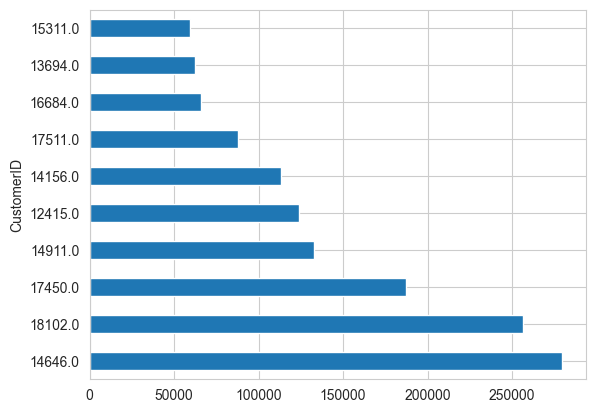

In [68]:
customer_rev = df.groupby("CustomerID")["Revenue"].sum().nlargest(10)
customer_rev.plot(kind='barh')

## Revenue By Country

<Axes: ylabel='Country'>

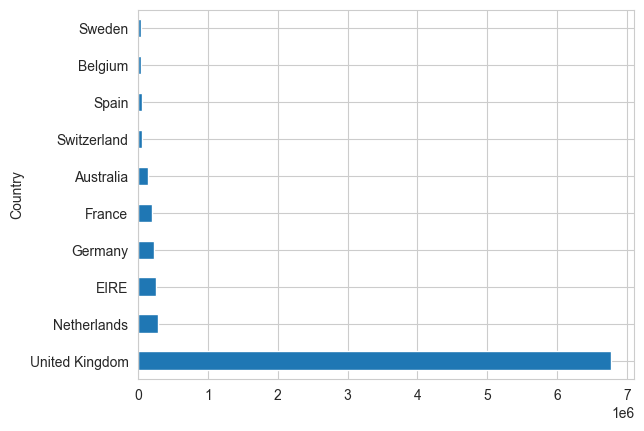

In [69]:
country_rev = df.groupby("Country")["Revenue"].sum().nlargest(10)
country_rev.plot(kind='barh')

# Contribution of Top Customers

In [71]:
cum_perc = customer_rev.cumsum() / customer_rev.sum() * 100

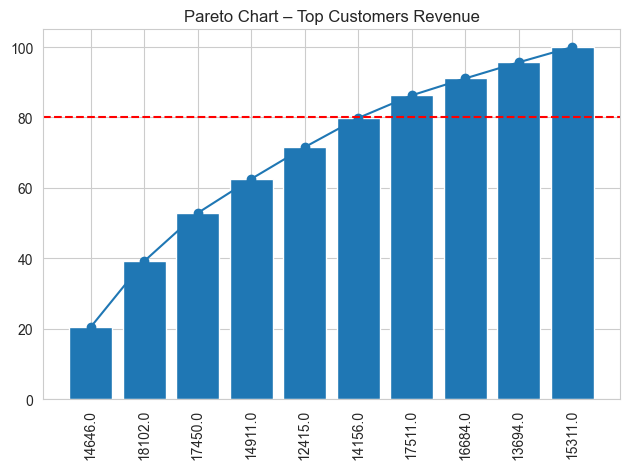

In [74]:
plt.Figure(figsize=(10,5))

# bar
plt.bar(customer_rev.index.astype(str),cum_perc.values)


# cumulative line
plt.plot(customer_rev.index.astype(str),cum_perc.values,'o-')


plt.axhline(80, color='red', linestyle='--')  # 80% line
plt.xticks(rotation=90)
plt.title("Pareto Chart – Top Customers Revenue")
plt.tight_layout()
plt.show()


# understand full code ----------


The top customers sorted by revenue

A cumulative line showing how much total revenue these customers contribute

A red 80% line showing where the Pareto principle (80/20 rule) hits

Only a few customers are giving most of the money.
If they stop buying, the business will lose a lot of revenue.

In [ ]:
# https://chatgpt.com/g/g-p-69242657fc38819196c315137536cdfe/c/69242801-3ed8-8320-92e6-46855aa2123c